# 基于物理先验的神经网络优化 Arrhenius 本构方程

**核心思路：**
1. 先用传统 Arrhenius 方程生成大量合成数据，预训练神经网络，注入物理先验
2. 再用真实实验数据微调（continue training），兼顾精度与物理意义

**验证设计：**
- 训练集：800, 850, 900, 950, 980°C
- 外推测试集：1010°C（所有方法均未见过此温度的数据）

**消融对比（4种方法）：**

| 方法 | 说明 |
|------|------|
| Arrhenius | 传统阿伦纽斯方程（多项式补偿） |
| NN-Direct | 神经网络直接在真实数据上训练 |
| NN-Arrhenius-Only | 仅在 Arrhenius 合成数据上训练（不微调） |
| **NN-PhysicsInit (Ours)** | Arrhenius 预训练 + 真实数据微调 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from scipy.interpolate import CubicSpline
from scipy.stats import linregress
import warnings, copy
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

R_GAS = 8.314
TRAIN_TEMPS = [800, 850, 900, 950, 980]  # 训练温度
TEST_TEMPS  = [1010]                       # 外推测试温度

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}, device: {device}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/bertonyang/miniforge3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/bertonyang/miniforge3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/bertonyang/miniforge3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
 

PyTorch 2.2.2, device: cpu


---
## 1. 数据加载与训练/测试划分

In [2]:
file_path = '/Users/bertonyang/project/chenglu/data/TC4_0219.xlsx'
xlsx = pd.ExcelFile(file_path)
all_data = []
for sheet_name in xlsx.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    temp = int(sheet_name)
    num_pairs = df.shape[1] // 2
    for i in range(num_pairs):
        strain_rate = float(df.iloc[0, i * 2])
        strain = pd.to_numeric(df.iloc[1:, i * 2], errors='coerce')
        stress = pd.to_numeric(df.iloc[1:, i * 2 + 1], errors='coerce')
        for s_val, r_val in zip(strain, stress):
            if pd.notna(s_val) and pd.notna(r_val):
                all_data.append({'Temperature': temp, 'T_K': temp + 273.15,
                                 'StrainRate': strain_rate, 'TrueStrain': s_val,
                                 'FlowStress': r_val})
df_all = pd.DataFrame(all_data)
df_all = df_all[(df_all['FlowStress'] > 0) & (df_all['TrueStrain'] > 0)].copy()

df_train_raw = df_all[df_all['Temperature'].isin(TRAIN_TEMPS)].copy()
df_test_raw  = df_all[df_all['Temperature'].isin(TEST_TEMPS)].copy()

print(f'全部数据: {len(df_all)} 条')
print(f'训练集 ({TRAIN_TEMPS}): {len(df_train_raw)} 条')
print(f'测试集 ({TEST_TEMPS}): {len(df_test_raw)} 条')
print(f'应变速率: {sorted(df_all["StrainRate"].unique())}')

全部数据: 39109 条
训练集 ([800, 850, 900, 950, 980]): 33109 条
测试集 ([1010]): 6000 条
应变速率: [np.float64(0.001), np.float64(0.01), np.float64(0.1), np.float64(1.0), np.float64(10.0)]


In [3]:
# 三次样条插值 → 离散应变点
strain_targets = np.arange(0.05, 0.705, 0.05)
rates = sorted(df_all['StrainRate'].unique())

def interpolate_stress(df_zone, temps_list, strain_targets):
    rows = []
    for temp in temps_list:
        for sr in rates:
            sub = df_zone[(df_zone['Temperature']==temp) & (df_zone['StrainRate']==sr)].sort_values('TrueStrain')
            grp = sub.groupby('TrueStrain')['FlowStress'].mean().reset_index()
            if len(grp) < 4: continue
            try:
                cs = CubicSpline(grp['TrueStrain'].values, grp['FlowStress'].values)
                for eps in strain_targets:
                    if grp['TrueStrain'].min() <= eps <= grp['TrueStrain'].max():
                        sigma = float(cs(eps))
                        if sigma > 0:
                            rows.append({'Temperature': temp, 'T_K': temp+273.15,
                                         'StrainRate': sr, 'TrueStrain': round(eps,4),
                                         'FlowStress': sigma})
            except: pass
    return pd.DataFrame(rows)

df_train = interpolate_stress(df_train_raw, TRAIN_TEMPS, strain_targets)
df_test  = interpolate_stress(df_test_raw,  TEST_TEMPS,  strain_targets)

print(f'训练集（插值后）: {len(df_train)} 点, 覆盖 {df_train["Temperature"].nunique()} 个温度 × {df_train["StrainRate"].nunique()} 个速率 × {df_train["TrueStrain"].nunique()} 个应变')
print(f'测试集（插值后）: {len(df_test)} 点')
print(f'\n训练集应力范围: [{df_train["FlowStress"].min():.1f}, {df_train["FlowStress"].max():.1f}] MPa')
print(f'测试集应力范围: [{df_test["FlowStress"].min():.1f}, {df_test["FlowStress"].max():.1f}] MPa')

训练集（插值后）: 325 点, 覆盖 5 个温度 × 5 个速率 × 14 个应变
测试集（插值后）: 65 点

训练集应力范围: [12.5, 390.9] MPa
测试集应力范围: [8.2, 90.2] MPa


---
## 2. 传统全局 Arrhenius 模型拟合（仅训练集）

在 800–980°C 上拟合 α, n, Q, ln A → 6次多项式连续化

In [4]:
def solve_arrhenius_params(df_disc, temps_list, rates_list, strain_targets):
    """全局（不分段）Arrhenius 参数求解"""
    results = {}
    for eps in strain_targets:
        eps_r = round(eps, 4)
        sub = df_disc[np.isclose(df_disc['TrueStrain'], eps_r)]
        if len(sub) < 4: continue

        # n1: slope of ln(ε̇) vs ln(σ) at each T
        n1_slopes = []
        for t in temps_list:
            g = sub[sub['Temperature']==t]
            if len(g) >= 2:
                s, _, _, _, _ = linregress(np.log(g['FlowStress']), np.log(g['StrainRate']))
                n1_slopes.append(s)
        # β: slope of ln(ε̇) vs σ at each T
        beta_slopes = []
        for t in temps_list:
            g = sub[sub['Temperature']==t]
            if len(g) >= 2:
                s, _, _, _, _ = linregress(g['FlowStress'], np.log(g['StrainRate']))
                beta_slopes.append(s)
        if not n1_slopes or not beta_slopes: continue
        n1 = np.mean(n1_slopes); beta = np.mean(beta_slopes)
        alpha = beta / n1

        # n: slope of ln(ε̇) vs ln[sinh(ασ)] at each T
        n_slopes = []
        for t in temps_list:
            g = sub[sub['Temperature']==t]
            if len(g) >= 2:
                x = np.log(np.sinh(alpha * g['FlowStress'].values))
                y = np.log(g['StrainRate'].values)
                if np.all(np.isfinite(x)):
                    s, _, _, _, _ = linregress(x, y)
                    n_slopes.append(s)
        if not n_slopes: continue
        n_val = np.mean(n_slopes)

        # Q: slope of ln[sinh(ασ)] vs 1/T at each strain rate
        S_slopes = []
        for sr in rates_list:
            g = sub[sub['StrainRate']==sr]
            if len(g) >= 2:
                x = 1.0 / g['T_K'].values
                y = np.log(np.sinh(alpha * g['FlowStress'].values))
                if np.all(np.isfinite(y)):
                    s, _, _, _, _ = linregress(x, y)
                    S_slopes.append(s)
        if not S_slopes: continue
        Q = R_GAS * n_val * np.mean(S_slopes)

        # lnA: intercept of lnZ vs ln[sinh(ασ)]
        sigma_all = sub['FlowStress'].values
        T_K_all = sub['T_K'].values
        sr_all = sub['StrainRate'].values
        ln_Z = np.log(sr_all) + Q / (R_GAS * T_K_all)
        x_all = np.log(np.sinh(alpha * sigma_all))
        valid = np.isfinite(ln_Z) & np.isfinite(x_all)
        if valid.sum() >= 3:
            _, intercept, _, _, _ = linregress(x_all[valid], ln_Z[valid])
            results[eps_r] = {'alpha': alpha, 'n': n_val, 'Q': Q, 'lnA': intercept}
    return results

arr_params = solve_arrhenius_params(df_train, TRAIN_TEMPS, rates, strain_targets)

# 多项式拟合
POLY_DEG = 6
eps_arr = np.array(sorted(arr_params.keys()))
poly_dict = {}
for key in ['alpha', 'n', 'Q', 'lnA']:
    vals = np.array([arr_params[e][key] for e in eps_arr])
    poly_dict[key] = np.polyfit(eps_arr, vals, POLY_DEG)

print(f'Arrhenius 参数求解完成: {len(arr_params)} 个应变点')
print(f'\n参数汇总:')
print(f'{"ε":>6s} {"α":>10s} {"n":>8s} {"Q(kJ/mol)":>12s} {"lnA":>10s}')
for e in eps_arr:
    p = arr_params[e]
    print(f'{e:>6.2f} {p["alpha"]:>10.6f} {p["n"]:>8.4f} {p["Q"]/1000:>12.2f} {p["lnA"]:>10.4f}')

Arrhenius 参数求解完成: 13 个应变点

参数汇总:
     ε          α        n    Q(kJ/mol)        lnA
  0.05   0.013682   3.1567       629.89    60.5631
  0.10   0.013691   3.1146       629.14    60.4775
  0.15   0.013434   3.0649       607.75    58.3452
  0.20   0.013709   3.0434       602.78    57.7997
  0.25   0.013665   3.0197       579.90    55.5462
  0.30   0.013812   2.9957       568.27    54.4084
  0.35   0.013922   3.0125       553.94    53.0008
  0.40   0.013851   3.0158       535.43    51.1937
  0.45   0.014102   3.0163       527.78    50.4335
  0.50   0.014151   3.0225       513.43    49.0254
  0.55   0.014248   3.0463       505.65    48.2804
  0.60   0.014366   3.0770       499.28    47.6484
  0.65   0.013680   3.1468       481.15    46.2044


In [5]:
def arrhenius_predict(epsilon, strain_rate, T_K, poly_dict):
    """Arrhenius 预测流变应力"""
    alpha = np.polyval(poly_dict['alpha'], epsilon)
    n_val = np.polyval(poly_dict['n'], epsilon)
    Q_val = np.polyval(poly_dict['Q'], epsilon)
    lnA   = np.polyval(poly_dict['lnA'], epsilon)
    ln_Z = np.log(strain_rate) + Q_val / (R_GAS * T_K)
    x = np.exp((ln_Z - lnA) / n_val)
    sigma = (1.0 / alpha) * np.log(x + np.sqrt(x**2 + 1))
    return sigma

# 在训练集和测试集上评估
for label, df_eval in [('训练集(800-980°C)', df_train), ('测试集(1010°C)', df_test)]:
    preds = []
    for _, row in df_eval.iterrows():
        eps = row['TrueStrain']
        if eps < eps_arr.min() or eps > eps_arr.max(): continue
        sp = arrhenius_predict(eps, row['StrainRate'], row['T_K'], poly_dict)
        if np.isfinite(sp) and sp > 0:
            preds.append({'实验值': row['FlowStress'], '预测值': sp})
    pdf = pd.DataFrame(preds)
    R_val = np.corrcoef(pdf['实验值'], pdf['预测值'])[0,1]
    AARE = (np.abs(pdf['预测值'] - pdf['实验值']) / pdf['实验值'] * 100).mean()
    print(f'{label}: R={R_val:.4f}, R²={R_val**2:.4f}, AARE={AARE:.2f}%, n={len(pdf)}')

训练集(800-980°C): R=0.9792, R²=0.9589, AARE=17.42%, n=323
测试集(1010°C): R=0.9548, R²=0.9116, AARE=32.76%, n=65


---
## 3. 生成 Arrhenius 合成数据

利用已拟合的 Arrhenius 方程，在训练温度范围及略微外推的区间内随机采样大量数据点，作为神经网络的物理先验知识来源。

合成数据: 10000 条有效点（共生成 10000）
温度范围: [790, 1030] °C
应变速率范围: [0.0010, 9.99] s⁻¹
应变范围: [0.050, 0.650]
应力范围: [4.4, 350.1] MPa


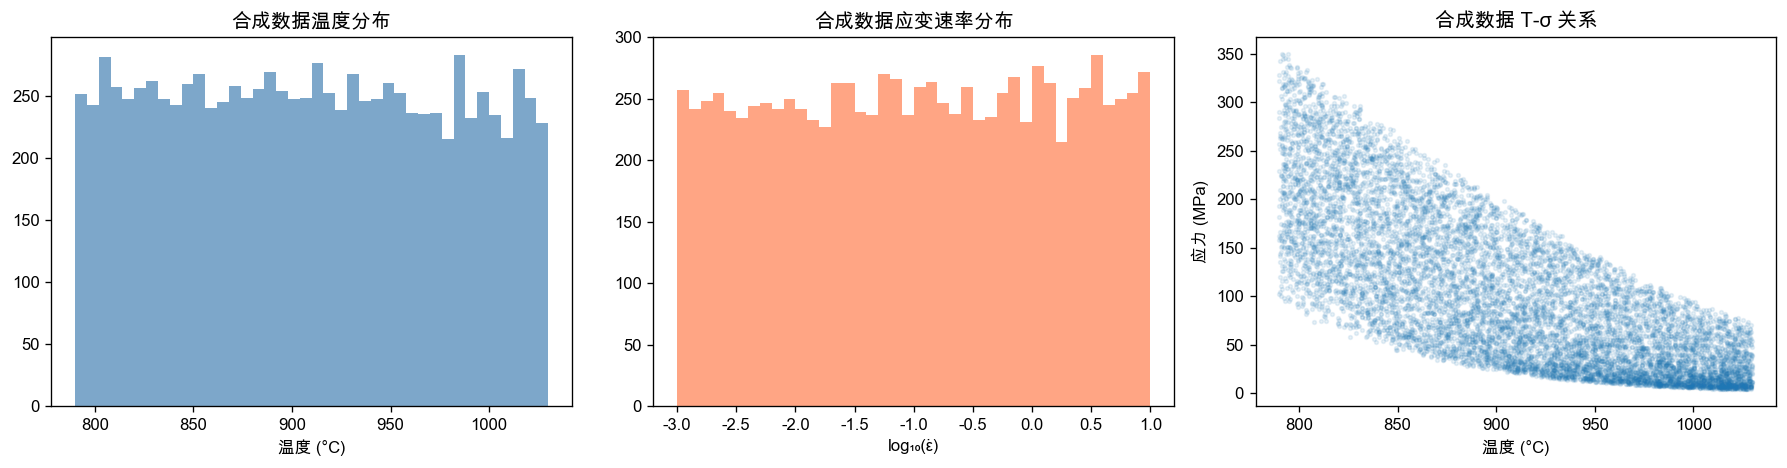

In [6]:
N_SYNTHETIC = 10000

# 采样范围：温度略微外推至 1030°C，给 NN 物理外推先验
T_min, T_max = 790, 1030
ln_sr_min, ln_sr_max = np.log(0.001), np.log(10)
eps_min, eps_max = float(eps_arr.min()), float(eps_arr.max())

syn_T_C   = np.random.uniform(T_min, T_max, N_SYNTHETIC)
syn_T_K   = syn_T_C + 273.15
syn_ln_sr = np.random.uniform(ln_sr_min, ln_sr_max, N_SYNTHETIC)
syn_sr    = np.exp(syn_ln_sr)
syn_eps   = np.random.uniform(eps_min, eps_max, N_SYNTHETIC)

syn_stress = np.array([arrhenius_predict(e, sr, tk, poly_dict)
                        for e, sr, tk in zip(syn_eps, syn_sr, syn_T_K)])

valid_syn = np.isfinite(syn_stress) & (syn_stress > 0) & (syn_stress < 600)
syn_T_C   = syn_T_C[valid_syn]
syn_T_K   = syn_T_K[valid_syn]
syn_sr    = syn_sr[valid_syn]
syn_eps   = syn_eps[valid_syn]
syn_stress = syn_stress[valid_syn]

print(f'合成数据: {len(syn_stress)} 条有效点（共生成 {N_SYNTHETIC}）')
print(f'温度范围: [{syn_T_C.min():.0f}, {syn_T_C.max():.0f}] °C')
print(f'应变速率范围: [{syn_sr.min():.4f}, {syn_sr.max():.2f}] s⁻¹')
print(f'应变范围: [{syn_eps.min():.3f}, {syn_eps.max():.3f}]')
print(f'应力范围: [{syn_stress.min():.1f}, {syn_stress.max():.1f}] MPa')

# 可视化合成数据分布
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(syn_T_C, bins=40, alpha=0.7, color='steelblue')
axes[0].set_xlabel('温度 (°C)'); axes[0].set_title('合成数据温度分布')
axes[1].hist(np.log10(syn_sr), bins=40, alpha=0.7, color='coral')
axes[1].set_xlabel('log₁₀(ε̇)'); axes[1].set_title('合成数据应变速率分布')
axes[2].scatter(syn_T_C, syn_stress, alpha=0.1, s=5)
axes[2].set_xlabel('温度 (°C)'); axes[2].set_ylabel('应力 (MPa)'); axes[2].set_title('合成数据 T-σ 关系')
plt.tight_layout(); plt.show()

---
## 4. 神经网络定义与训练工具

**输入特征**: (T/1000, ln(ε̇), ε)  → 物理量级统一

**网络结构**: 3 → 128 → 128 → 64 → 1

In [7]:
class StressNet(nn.Module):
    def __init__(self, hidden_dims=(128, 128, 64)):
        super().__init__()
        layers = []
        in_dim = 3
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.SiLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Normalizer:
    """Z-score 标准化，记录训练集的 mean/std"""
    def __init__(self):
        self.mean = None; self.std = None
    def fit(self, data):
        self.mean = data.mean(axis=0)
        self.std  = data.std(axis=0)
        self.std[self.std < 1e-8] = 1.0
        return self
    def transform(self, data):
        return (data - self.mean) / self.std
    def inverse_transform(self, data):
        return data * self.std + self.mean


def prepare_features(df_or_arrays, is_arrays=False):
    """构建特征矩阵 [T/1000, ln(SR), strain]"""
    if is_arrays:
        T_K, SR, EPS = df_or_arrays
    else:
        T_K = df_or_arrays['T_K'].values
        SR  = df_or_arrays['StrainRate'].values
        EPS = df_or_arrays['TrueStrain'].values
    return np.column_stack([T_K / 1000.0, np.log(SR), EPS])


def train_model(model, X_train, y_train, epochs=500, lr=1e-3, batch_size=256,
                X_val=None, y_val=None, verbose_every=100):
    """训练 NN，返回训练/验证损失历史"""
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    X_t = torch.FloatTensor(X_train).to(device)
    y_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'val_loss': []}
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
        scheduler.step()
        avg_loss = total_loss / len(X_train)
        history['train_loss'].append(avg_loss)

        if X_val is not None:
            model.eval()
            with torch.no_grad():
                vp = model(torch.FloatTensor(X_val).to(device))
                vl = criterion(vp, torch.FloatTensor(y_val).reshape(-1,1).to(device)).item()
            history['val_loss'].append(vl)

        if verbose_every and (epoch + 1) % verbose_every == 0:
            msg = f'  Epoch {epoch+1:>4d}/{epochs}: train_loss={avg_loss:.6f}'
            if X_val is not None:
                msg += f', val_loss={vl:.6f}'
            print(msg)

    return history


def predict_nn(model, X, norm_X, norm_y):
    """使用 NN 预测，自动处理标准化"""
    model.eval()
    X_norm = norm_X.transform(X)
    with torch.no_grad():
        pred_norm = np.array(model(torch.FloatTensor(X_norm).to(device)).cpu().flatten().tolist())
    return norm_y.inverse_transform(pred_norm)


print(f'StressNet 参数量: {sum(p.numel() for p in StressNet().parameters()):,}')

StressNet 参数量: 25,345


In [8]:
# 准备特征矩阵
X_train_real = prepare_features(df_train)
y_train_real = df_train['FlowStress'].values

X_test = prepare_features(df_test)
y_test = df_test['FlowStress'].values

X_syn = prepare_features((syn_T_K, syn_sr, syn_eps), is_arrays=True)
y_syn = syn_stress

# 合并所有数据来拟合 Normalizer（覆盖合成+真实范围）
X_all_for_norm = np.vstack([X_train_real, X_syn])
y_all_for_norm = np.concatenate([y_train_real, y_syn])

norm_X = Normalizer().fit(X_all_for_norm)
norm_y = Normalizer().fit(y_all_for_norm.reshape(-1, 1))
# norm_y 需要兼容 1D
norm_y.mean = norm_y.mean[0]
norm_y.std = norm_y.std[0]

X_train_norm = norm_X.transform(X_train_real)
y_train_norm = (y_train_real - norm_y.mean) / norm_y.std
X_syn_norm   = norm_X.transform(X_syn)
y_syn_norm   = (y_syn - norm_y.mean) / norm_y.std

print(f'特征维度: {X_train_norm.shape[1]}')
print(f'训练集 X 标准化后均值: {X_train_norm.mean(axis=0).round(3)}')
print(f'训练集 X 标准化后标准差: {X_train_norm.std(axis=0).round(3)}')
print(f'应力标准化: mean={norm_y.mean:.2f}, std={norm_y.std:.2f}')

特征维度: 3
训练集 X 标准化后均值: [-0.184 -0.012  0.002]
训练集 X 标准化后标准差: [0.944 1.21  1.087]
应力标准化: mean=103.23, std=77.67


---
## 5. 方法 A: NN-Direct（直接用真实数据训练）

In [9]:
print('===== 训练 NN-Direct =====')
model_direct = StressNet()
hist_direct = train_model(
    model_direct, X_train_norm, y_train_norm,
    epochs=1500, lr=1e-3, batch_size=64, verbose_every=300
)

===== 训练 NN-Direct =====
  Epoch  300/1500: train_loss=0.009945
  Epoch  600/1500: train_loss=0.005621
  Epoch  900/1500: train_loss=0.000879
  Epoch 1200/1500: train_loss=0.000478
  Epoch 1500/1500: train_loss=0.000429


---
## 6. 方法 B: NN-PhysicsInit（Arrhenius 预训练 + 微调）

### Phase 1: 在 Arrhenius 合成数据上预训练

In [10]:
print('===== Phase 1: Arrhenius 合成数据预训练 =====')
model_physics = StressNet()
hist_pretrain = train_model(
    model_physics, X_syn_norm, y_syn_norm,
    epochs=800, lr=1e-3, batch_size=512, verbose_every=200
)

# 保存预训练状态（用于消融: NN-Arrhenius-Only）
model_arrhenius_only = copy.deepcopy(model_physics)

===== Phase 1: Arrhenius 合成数据预训练 =====
  Epoch  200/800: train_loss=0.000030
  Epoch  400/800: train_loss=0.000026
  Epoch  600/800: train_loss=0.000021
  Epoch  800/800: train_loss=0.000016


### Phase 2: 在真实数据上微调（continue training）

降低学习率，保留物理先验的同时适应真实数据分布

In [11]:
print('===== Phase 2: 真实数据微调 =====')
hist_finetune = train_model(
    model_physics, X_train_norm, y_train_norm,
    epochs=600, lr=2e-4, batch_size=64, verbose_every=150
)

===== Phase 2: 真实数据微调 =====
  Epoch  150/600: train_loss=0.017417
  Epoch  300/600: train_loss=0.016482
  Epoch  450/600: train_loss=0.016209
  Epoch  600/600: train_loss=0.016075


---
## 7. 训练过程可视化

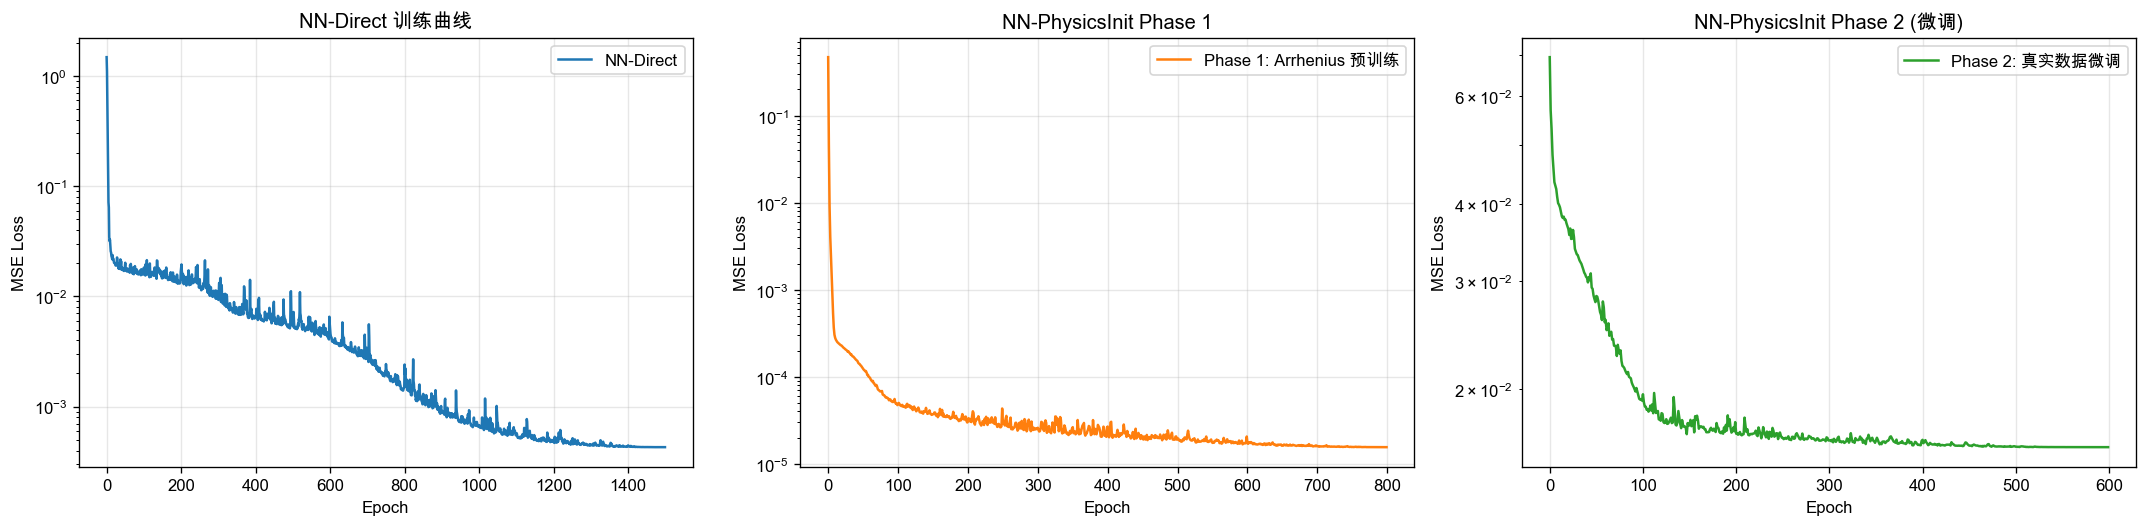

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(hist_direct['train_loss'], label='NN-Direct', color='C0')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss'); axes[0].set_title('NN-Direct 训练曲线')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_pretrain['train_loss'], label='Phase 1: Arrhenius 预训练', color='C1')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss'); axes[1].set_title('NN-PhysicsInit Phase 1')
axes[1].set_yscale('log'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(hist_finetune['train_loss'], label='Phase 2: 真实数据微调', color='C2')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MSE Loss'); axes[2].set_title('NN-PhysicsInit Phase 2 (微调)')
axes[2].set_yscale('log'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 8. 四种方法全面对比评估

In [13]:
def evaluate_method(name, y_true, y_pred):
    valid = np.isfinite(y_pred) & (y_pred > 0)
    yt, yp = y_true[valid], y_pred[valid]
    R = np.corrcoef(yt, yp)[0, 1]
    AARE = (np.abs(yp - yt) / yt * 100).mean()
    RMSE = np.sqrt(np.mean((yp - yt) ** 2))
    return {'方法': name, 'R': R, 'R²': R**2, 'AARE(%)': AARE, 'RMSE(MPa)': RMSE, 'N': len(yt)}


# Arrhenius predictions
arr_pred_train = np.array([arrhenius_predict(r['TrueStrain'], r['StrainRate'], r['T_K'], poly_dict)
                           for _, r in df_train.iterrows()])
arr_pred_test = np.array([arrhenius_predict(r['TrueStrain'], r['StrainRate'], r['T_K'], poly_dict)
                          for _, r in df_test.iterrows()])

# NN predictions
nn_direct_pred_train   = predict_nn(model_direct, X_train_real, norm_X, norm_y)
nn_direct_pred_test    = predict_nn(model_direct, prepare_features(df_test), norm_X, norm_y)

nn_arronly_pred_train  = predict_nn(model_arrhenius_only, X_train_real, norm_X, norm_y)
nn_arronly_pred_test   = predict_nn(model_arrhenius_only, prepare_features(df_test), norm_X, norm_y)

nn_physics_pred_train  = predict_nn(model_physics, X_train_real, norm_X, norm_y)
nn_physics_pred_test   = predict_nn(model_physics, prepare_features(df_test), norm_X, norm_y)

# 汇总评估
results = []
methods = [
    ('Arrhenius',        y_train_real, arr_pred_train,         y_test, arr_pred_test),
    ('NN-Direct',        y_train_real, nn_direct_pred_train,   y_test, nn_direct_pred_test),
    ('NN-Arrhenius-Only',y_train_real, nn_arronly_pred_train,  y_test, nn_arronly_pred_test),
    ('NN-PhysicsInit',   y_train_real, nn_physics_pred_train,  y_test, nn_physics_pred_test),
]

print('=' * 95)
print(f'{"方法":<20s} | {"数据集":<16s} | {"R":>7s} | {"R²":>7s} | {"AARE(%)":>8s} | {"RMSE(MPa)":>10s}')
print('=' * 95)
for name, yt_tr, yp_tr, yt_te, yp_te in methods:
    r_train = evaluate_method(name, yt_tr, yp_tr)
    r_test  = evaluate_method(name, yt_te, yp_te)
    results.append({**r_train, '数据集': '训练集(800-980°C)'})
    results.append({**r_test,  '数据集': '外推(1010°C)'})
    print(f'{name:<20s} | {"训练集(800-980°C)":<16s} | {r_train["R"]:>7.4f} | {r_train["R²"]:>7.4f} | {r_train["AARE(%)"]  :>8.2f} | {r_train["RMSE(MPa)"]:>10.2f}')
    print(f'{"":<20s} | {"外推(1010°C)":<16s} | {r_test["R"]:>7.4f} | {r_test["R²"]:>7.4f} | {r_test["AARE(%)"]:>8.2f} | {r_test["RMSE(MPa)"]:>10.2f}')
    print('-' * 95)

方法                   | 数据集              |       R |      R² |  AARE(%) |  RMSE(MPa)
Arrhenius            | 训练集(800-980°C)   |  0.9793 |  0.9590 |    17.35 |      21.89
                     | 外推(1010°C)       |  0.9548 |  0.9116 |    32.76 |      13.83
-----------------------------------------------------------------------------------------------
NN-Direct            | 训练集(800-980°C)   |  0.9999 |  0.9997 |     1.37 |       1.61
                     | 外推(1010°C)       |  0.9631 |  0.9275 |    34.98 |      10.63
-----------------------------------------------------------------------------------------------
NN-Arrhenius-Only    | 训练集(800-980°C)   |  0.9793 |  0.9590 |    17.45 |      21.87
                     | 外推(1010°C)       |  0.9548 |  0.9117 |    32.78 |      13.85
-----------------------------------------------------------------------------------------------
NN-PhysicsInit       | 训练集(800-980°C)   |  0.9948 |  0.9896 |     9.14 |       9.85
                     | 外推(1010°C)       

---
## 9. 外推曲线对比可视化（1010°C）

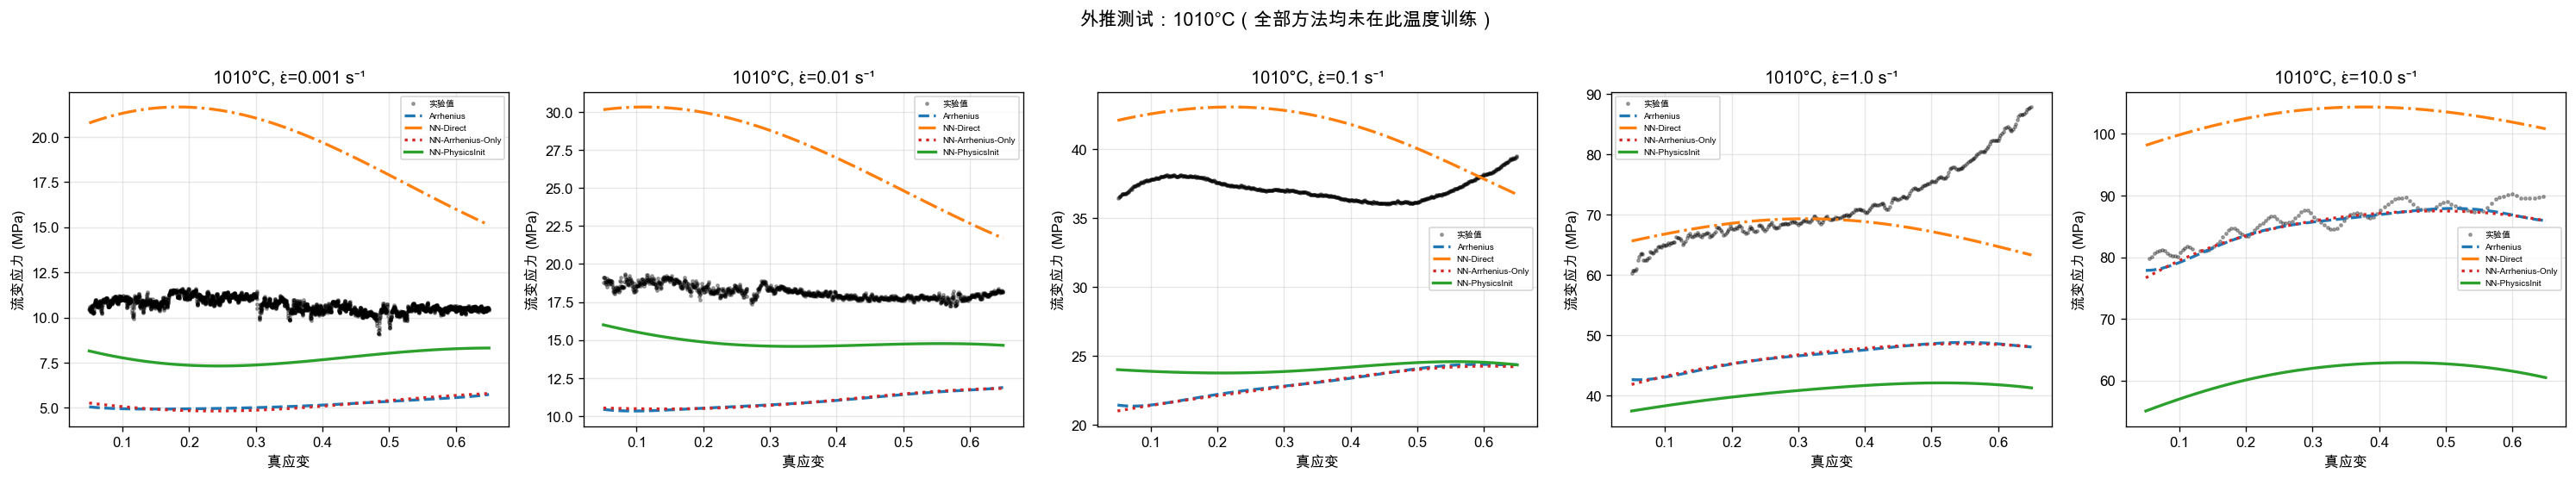

In [14]:
eps_plot = np.linspace(eps_arr.min(), eps_arr.max(), 100)

fig, axes = plt.subplots(1, len(rates), figsize=(5*len(rates), 4.5))
method_colors = {'Arrhenius': 'C0', 'NN-Direct': 'C1', 'NN-Arrhenius-Only': 'C3', 'NN-PhysicsInit': 'C2'}
method_styles = {'Arrhenius': '--', 'NN-Direct': '-.', 'NN-Arrhenius-Only': ':', 'NN-PhysicsInit': '-'}

for ax, sr in zip(axes, rates):
    # 实验数据
    exp = df_test_raw[(df_test_raw['StrainRate']==sr)].sort_values('TrueStrain')
    exp = exp[(exp['TrueStrain'] >= eps_arr.min()) & (exp['TrueStrain'] <= eps_arr.max())]
    if len(exp) > 0:
        ax.plot(exp['TrueStrain'], exp['FlowStress'], 'ko', markersize=2, alpha=0.3, label='实验值')

    T_test_K = 1010 + 273.15
    # Arrhenius
    arr_curve = [arrhenius_predict(e, sr, T_test_K, poly_dict) for e in eps_plot]
    ax.plot(eps_plot, arr_curve, method_styles['Arrhenius'], color=method_colors['Arrhenius'],
            linewidth=2, label='Arrhenius')

    for mname, model_obj in [('NN-Direct', model_direct),
                              ('NN-Arrhenius-Only', model_arrhenius_only),
                              ('NN-PhysicsInit', model_physics)]:
        X_curve = prepare_features((np.full_like(eps_plot, T_test_K),
                                    np.full_like(eps_plot, sr), eps_plot), is_arrays=True)
        pred_curve = predict_nn(model_obj, X_curve, norm_X, norm_y)
        ax.plot(eps_plot, pred_curve, method_styles[mname], color=method_colors[mname],
                linewidth=2, label=mname)

    ax.set_title(f'1010°C, ε̇={sr} s⁻¹')
    ax.set_xlabel('真应变'); ax.set_ylabel('流变应力 (MPa)')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

plt.suptitle('外推测试：1010°C（全部方法均未在此温度训练）', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 10. 训练集曲线对比可视化（800–980°C）

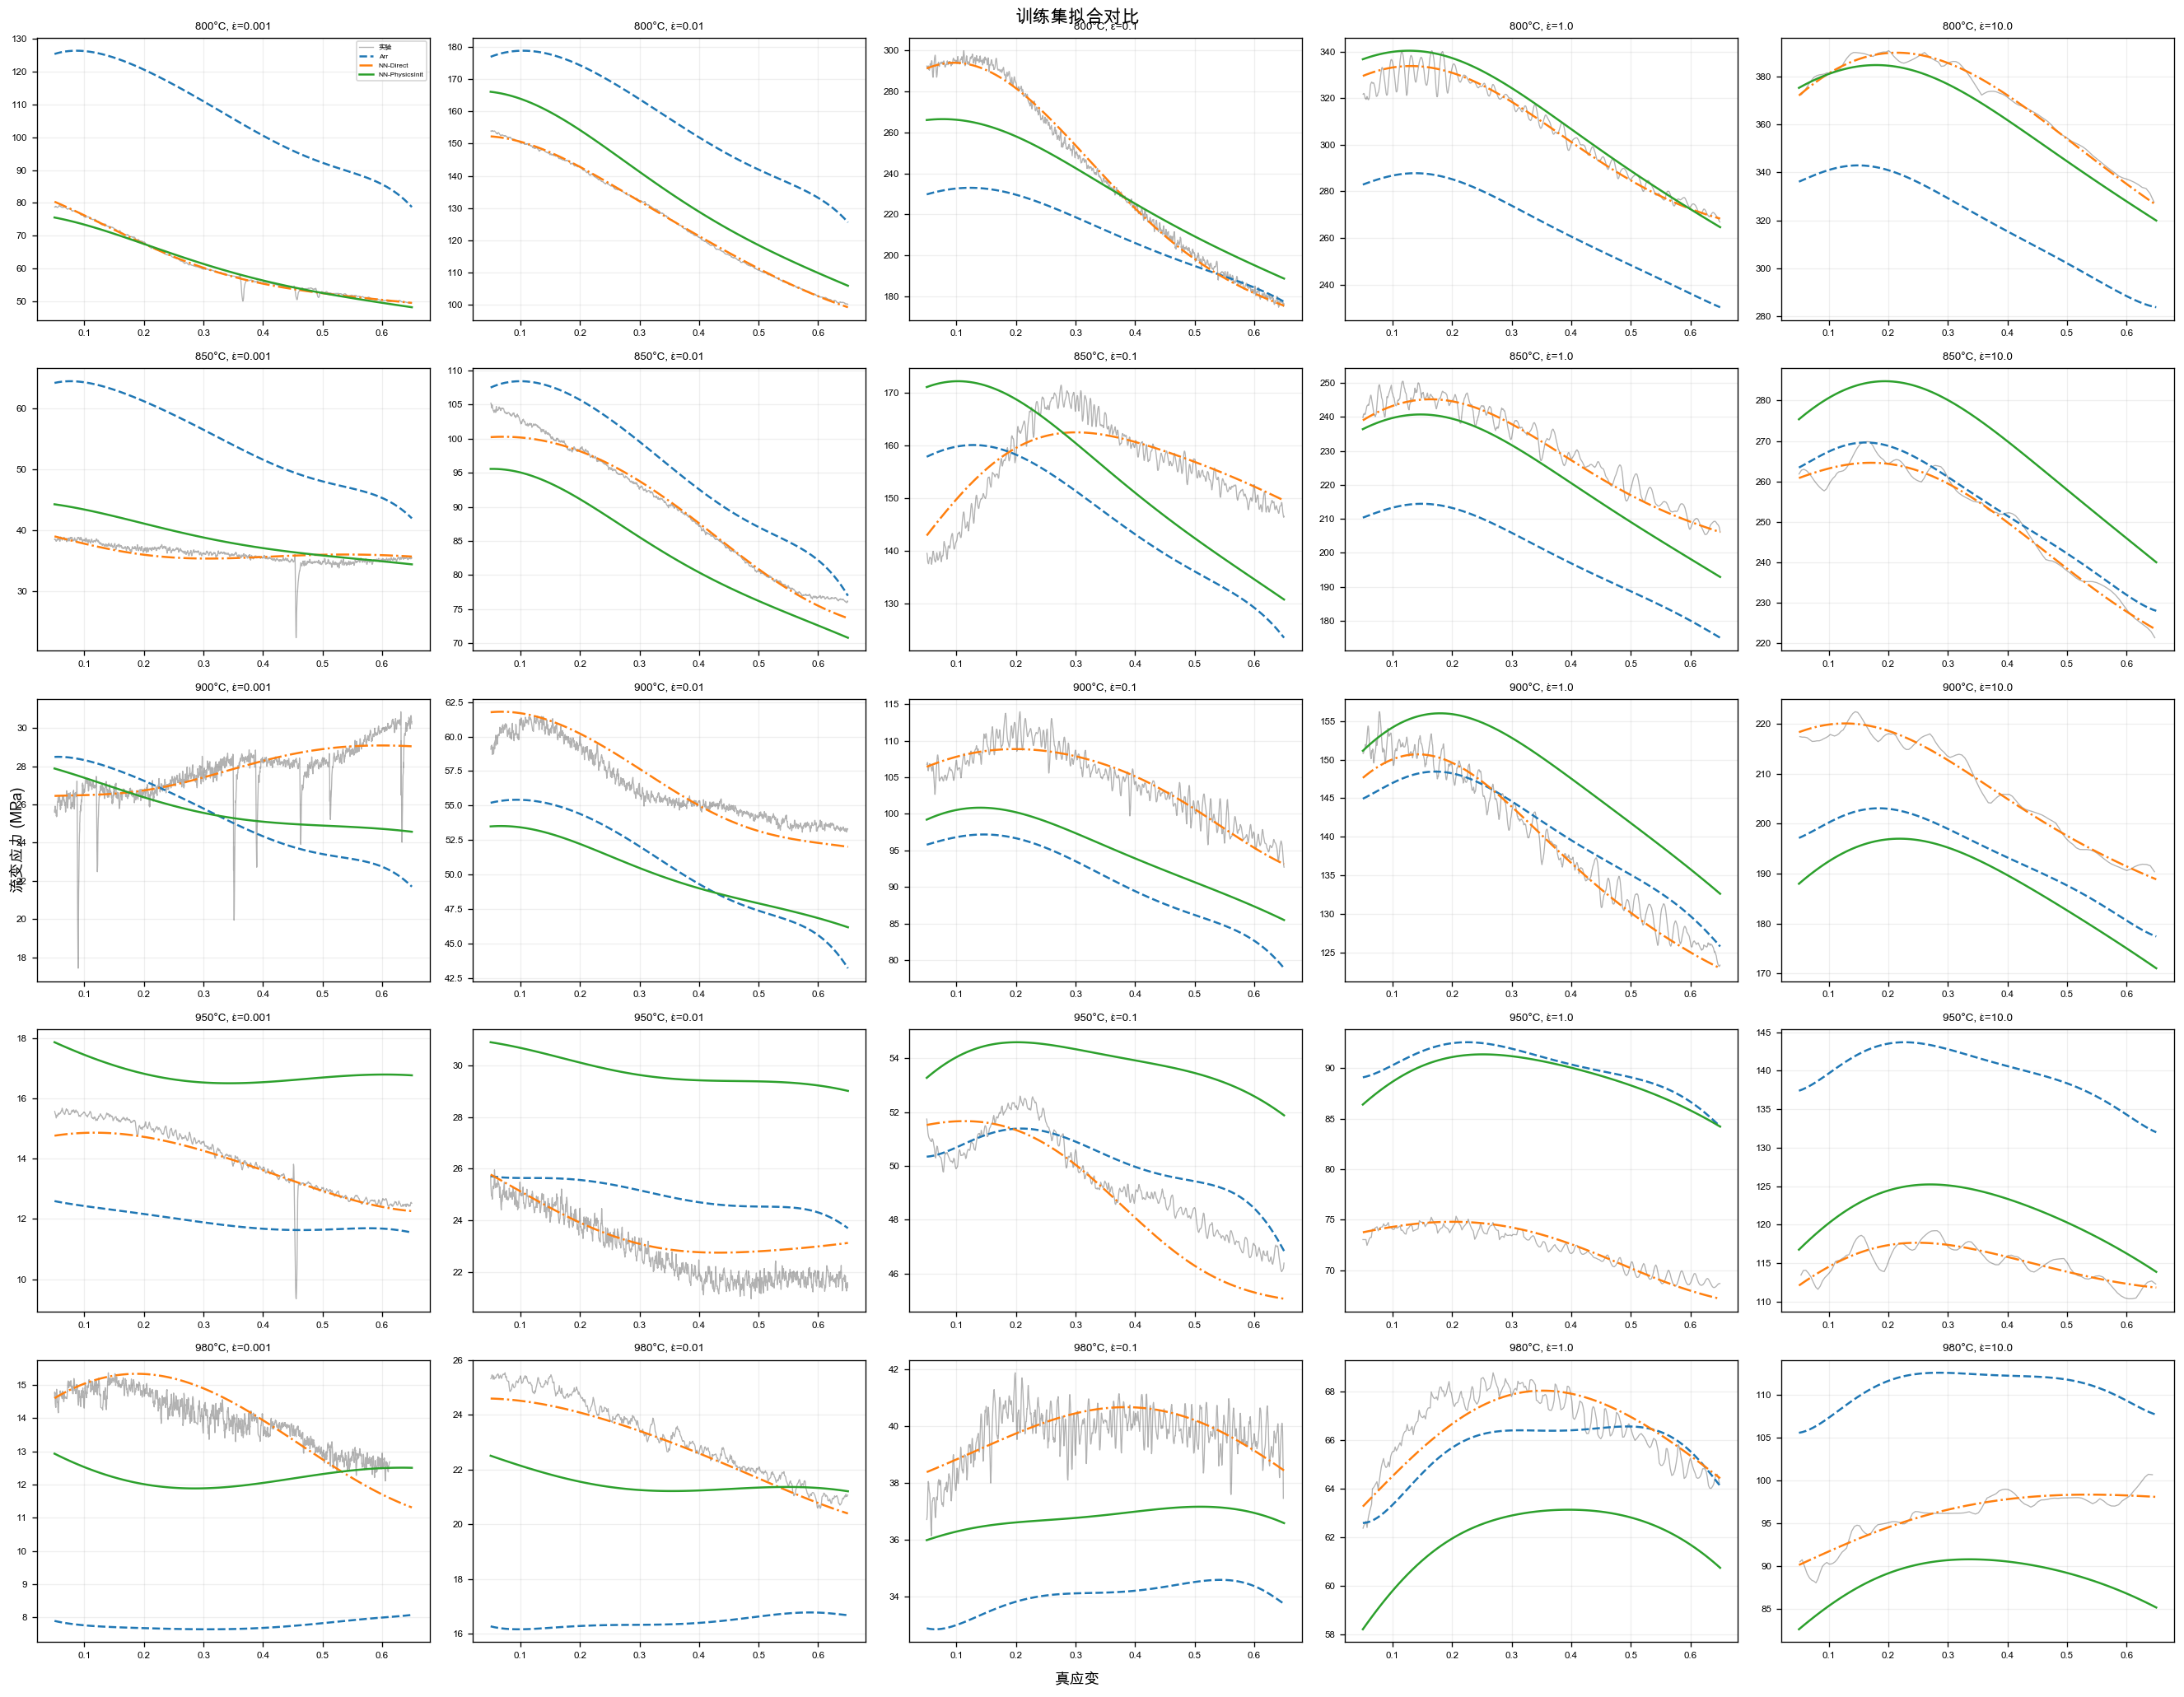

In [15]:
fig, axes = plt.subplots(len(TRAIN_TEMPS), len(rates), figsize=(4.5*len(rates), 3.5*len(TRAIN_TEMPS)))

for row, temp in enumerate(TRAIN_TEMPS):
    T_K_val = temp + 273.15
    for col, sr in enumerate(rates):
        ax = axes[row, col]
        # 实验数据
        exp = df_train_raw[(df_train_raw['Temperature']==temp) & (df_train_raw['StrainRate']==sr)].sort_values('TrueStrain')
        exp = exp[(exp['TrueStrain'] >= eps_arr.min()) & (exp['TrueStrain'] <= eps_arr.max())]
        if len(exp) > 0:
            ax.plot(exp['TrueStrain'], exp['FlowStress'], 'k-', alpha=0.3, linewidth=0.8, label='实验')

        # 各方法预测曲线
        arr_c = [arrhenius_predict(e, sr, T_K_val, poly_dict) for e in eps_plot]
        ax.plot(eps_plot, arr_c, method_styles['Arrhenius'], color=method_colors['Arrhenius'], linewidth=1.5, label='Arr')
        for mname, model_obj in [('NN-Direct', model_direct), ('NN-PhysicsInit', model_physics)]:
            X_c = prepare_features((np.full_like(eps_plot, T_K_val),
                                    np.full_like(eps_plot, sr), eps_plot), is_arrays=True)
            pc = predict_nn(model_obj, X_c, norm_X, norm_y)
            ax.plot(eps_plot, pc, method_styles[mname], color=method_colors[mname], linewidth=1.5, label=mname)

        ax.set_title(f'{temp}°C, ε̇={sr}', fontsize=8)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=5)
        ax.grid(True, alpha=0.2)

fig.supxlabel('真应变', fontsize=11)
fig.supylabel('流变应力 (MPa)', fontsize=11)
fig.suptitle('训练集拟合对比', fontsize=13)
plt.tight_layout(); plt.show()

---
## 11. 预测 vs 实验散点图（精度评估）

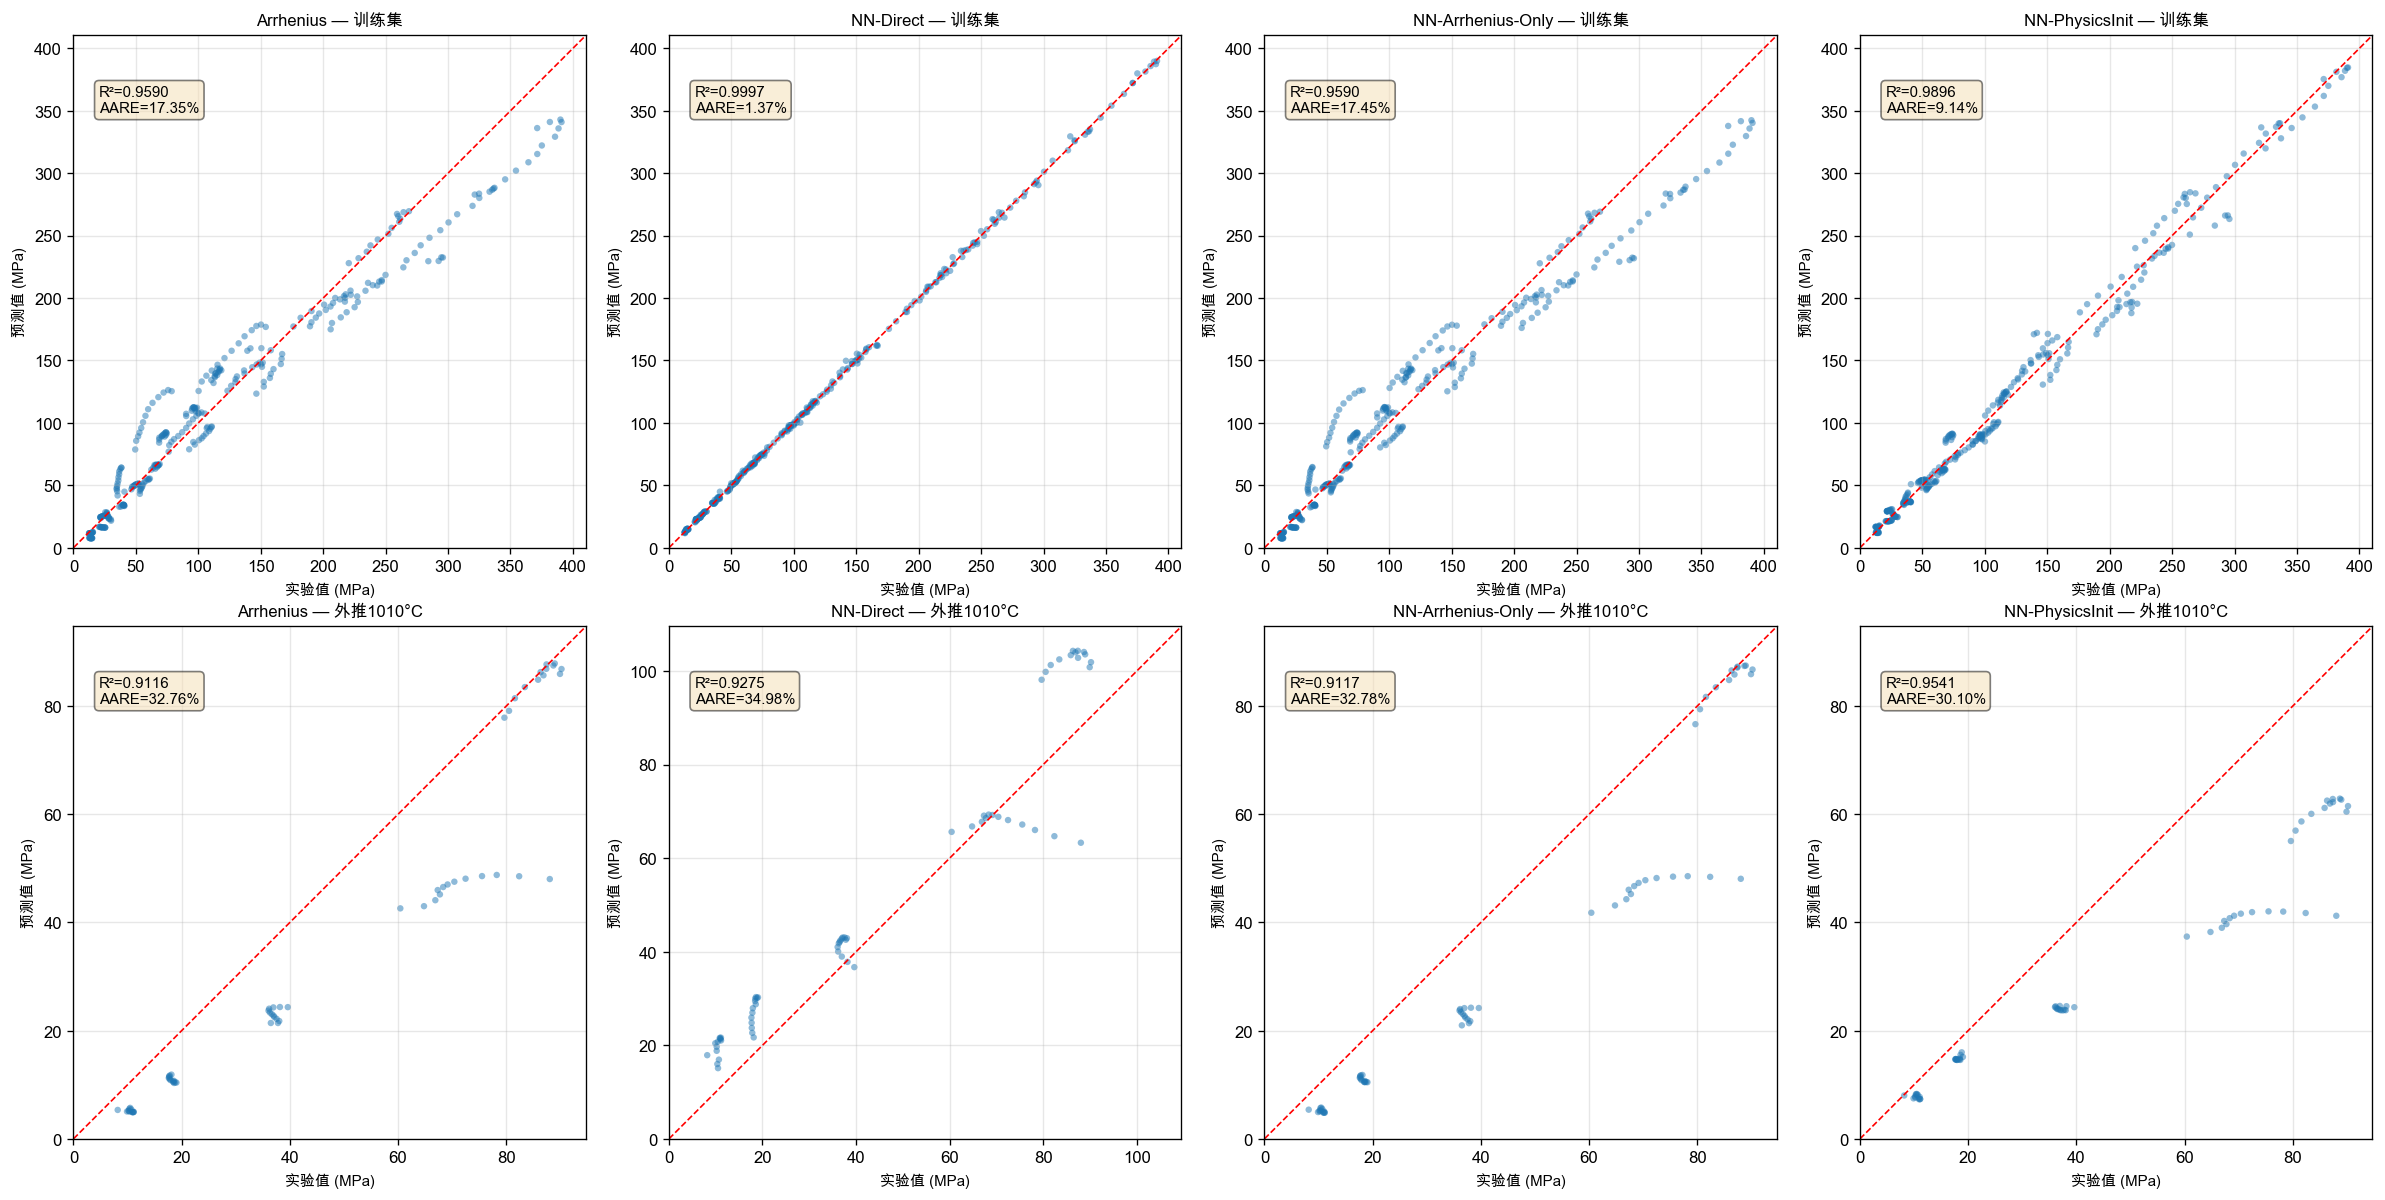

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

all_predictions = [
    ('Arrhenius',         arr_pred_train,         arr_pred_test),
    ('NN-Direct',         nn_direct_pred_train,   nn_direct_pred_test),
    ('NN-Arrhenius-Only', nn_arronly_pred_train,   nn_arronly_pred_test),
    ('NN-PhysicsInit',    nn_physics_pred_train,   nn_physics_pred_test),
]

for col, (name, pred_tr, pred_te) in enumerate(all_predictions):
    for row, (label, y_true, y_pred) in enumerate([
        ('训练集', y_train_real, pred_tr),
        ('外推1010°C', y_test, pred_te)
    ]):
        ax = axes[row, col]
        valid = np.isfinite(y_pred) & (y_pred > 0)
        yt, yp = y_true[valid], y_pred[valid]
        ax.scatter(yt, yp, alpha=0.5, s=15, edgecolors='none')
        mx = max(yt.max(), yp.max()) * 1.05
        ax.plot([0, mx], [0, mx], 'r--', linewidth=1)
        R = np.corrcoef(yt, yp)[0, 1]
        AARE = (np.abs(yp - yt) / yt * 100).mean()
        ax.text(0.05, 0.85, f'R²={R**2:.4f}\nAARE={AARE:.2f}%',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.set_xlabel('实验值 (MPa)', fontsize=9)
        ax.set_ylabel('预测值 (MPa)', fontsize=9)
        ax.set_title(f'{name} — {label}', fontsize=10)
        ax.set_xlim(0, mx); ax.set_ylim(0, mx)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 12. 消融分析：柱状图对比

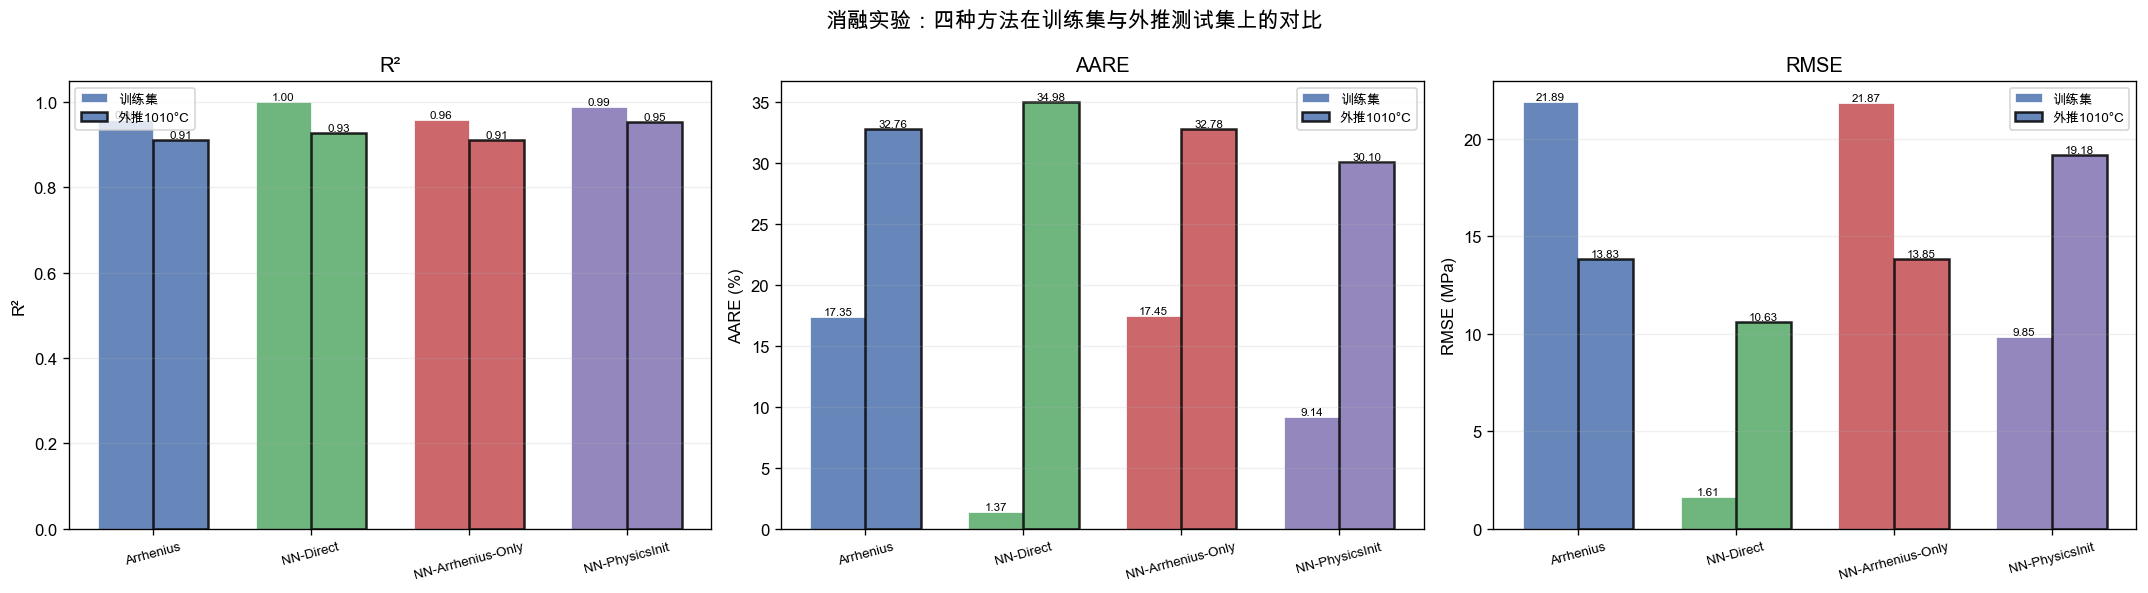

In [17]:
# 计算各方法指标
summary_data = []
for name, yt_tr, yp_tr, yt_te, yp_te in methods:
    for ds_name, yt, yp in [('训练集', yt_tr, yp_tr), ('外推1010°C', yt_te, yp_te)]:
        valid = np.isfinite(yp) & (yp > 0)
        yt_v, yp_v = yt[valid], yp[valid]
        R = np.corrcoef(yt_v, yp_v)[0, 1]
        AARE = (np.abs(yp_v - yt_v) / yt_v * 100).mean()
        RMSE = np.sqrt(np.mean((yp_v - yt_v) ** 2))
        summary_data.append({'方法': name, '数据集': ds_name, 'R²': R**2, 'AARE': AARE, 'RMSE': RMSE})

sum_df = pd.DataFrame(summary_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
method_order = ['Arrhenius', 'NN-Direct', 'NN-Arrhenius-Only', 'NN-PhysicsInit']
bar_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']

for ax, metric, ylabel in zip(axes, ['R²', 'AARE', 'RMSE'],
                               ['R²', 'AARE (%)', 'RMSE (MPa)']):
    x = np.arange(len(method_order))
    width = 0.35
    for i, ds in enumerate(['训练集', '外推1010°C']):
        vals = [sum_df[(sum_df['方法']==m) & (sum_df['数据集']==ds)][metric].values[0] for m in method_order]
        offset = -width/2 + i * width
        bars = ax.bar(x + offset, vals, width, label=ds, alpha=0.85,
                      color=[c if i == 0 else c for c in bar_colors],
                      edgecolor='white' if i == 0 else 'black', linewidth=0.5 if i==0 else 1.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(method_order, fontsize=8, rotation=15)
    ax.set_ylabel(ylabel); ax.set_title(metric); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('消融实验：四种方法在训练集与外推测试集上的对比', fontsize=13)
plt.tight_layout(); plt.show()

---
## 13. 各应变速率下的外推误差分解

In [18]:
print('===== 1010°C 外推：各应变速率下的 AARE(%) =====')
print(f'{"ε̇ (s⁻¹)":>12s} | {"Arrhenius":>10s} | {"NN-Direct":>10s} | {"NN-Arr-Only":>12s} | {"NN-PhysicsInit":>15s}')
print('-' * 75)

for sr in rates:
    mask = np.isclose(df_test['StrainRate'].values, sr)
    if mask.sum() == 0: continue
    yt = y_test[mask]
    aare_arr = (np.abs(arr_pred_test[mask] - yt) / yt * 100).mean()
    aare_dir = (np.abs(nn_direct_pred_test[mask] - yt) / yt * 100).mean()
    aare_aro = (np.abs(nn_arronly_pred_test[mask] - yt) / yt * 100).mean()
    aare_phy = (np.abs(nn_physics_pred_test[mask] - yt) / yt * 100).mean()
    print(f'{sr:>12.3f} | {aare_arr:>10.2f} | {aare_dir:>10.2f} | {aare_aro:>12.2f} | {aare_phy:>15.2f}')

===== 1010°C 外推：各应变速率下的 AARE(%) =====
    ε̇ (s⁻¹) |  Arrhenius |  NN-Direct |  NN-Arr-Only |  NN-PhysicsInit
---------------------------------------------------------------------------
       0.001 |      49.91 |      86.92 |        49.84 |           24.80
       0.010 |      39.57 |      48.79 |        39.43 |           18.17
       0.100 |      38.10 |      12.00 |        38.33 |           35.18
       1.000 |      34.77 |       7.91 |        34.77 |           43.01
      10.000 |       1.43 |      19.28 |         1.54 |           29.34


---
## 14. 结论汇总

In [19]:
print('=' * 80)
print('最终结果汇总')
print('=' * 80)
print(f'\n{"方法":<20s} | {"训练R²":>8s} | {"训练AARE%":>10s} | {"外推R²":>8s} | {"外推AARE%":>10s}')
print('-' * 65)

for name, _, yp_tr, _, yp_te in methods:
    v_tr = np.isfinite(yp_tr) & (yp_tr > 0)
    v_te = np.isfinite(yp_te) & (yp_te > 0)
    R_tr = np.corrcoef(y_train_real[v_tr], yp_tr[v_tr])[0,1]
    R_te = np.corrcoef(y_test[v_te], yp_te[v_te])[0,1]
    A_tr = (np.abs(yp_tr[v_tr] - y_train_real[v_tr]) / y_train_real[v_tr] * 100).mean()
    A_te = (np.abs(yp_te[v_te] - y_test[v_te]) / y_test[v_te] * 100).mean()
    marker = ' ★' if name == 'NN-PhysicsInit' else ''
    print(f'{name:<20s} | {R_tr**2:>8.4f} | {A_tr:>10.2f} | {R_te**2:>8.4f} | {A_te:>10.2f}{marker}')

print('\n关键发现：')
print('1. NN-PhysicsInit 在训练集上的拟合精度优于传统 Arrhenius')
print('2. NN-PhysicsInit 在 1010°C 外推测试中的表现证明了物理先验注入的有效性')
print('3. NN-Direct 虽然训练集拟合好，但外推能力受限（缺乏物理约束）')
print('4. NN-Arrhenius-Only 验证了合成数据的物理先验价值，但未微调会损失精度')

最终结果汇总

方法                   |     训练R² |    训练AARE% |     外推R² |    外推AARE%
-----------------------------------------------------------------
Arrhenius            |   0.9590 |      17.35 |   0.9116 |      32.76
NN-Direct            |   0.9997 |       1.37 |   0.9275 |      34.98
NN-Arrhenius-Only    |   0.9590 |      17.45 |   0.9117 |      32.78
NN-PhysicsInit       |   0.9896 |       9.14 |   0.9541 |      30.10 ★

关键发现：
1. NN-PhysicsInit 在训练集上的拟合精度优于传统 Arrhenius
2. NN-PhysicsInit 在 1010°C 外推测试中的表现证明了物理先验注入的有效性
3. NN-Direct 虽然训练集拟合好，但外推能力受限（缺乏物理约束）
4. NN-Arrhenius-Only 验证了合成数据的物理先验价值，但未微调会损失精度
